<a href="https://colab.research.google.com/github/yimarbriceon/ingenieria-conocimiento-uncp/blob/master/mis-trabajos/Sesion01_CicloVidaML_Brice%C3%B1oAlaya.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Configuración del Entorno

In [1]:
# Librerías principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)
import joblib

# Configuración visual
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print('✅ Entorno configurado correctamente.')

✅ Entorno configurado correctamente.


Carga de Datos

In [2]:
# Cargar el dataset de billetes
df = pd.read_csv('BankNoteAuthentication.csv')

# Renombrar la columna 'class' a 'target'
df.rename(columns={'class': 'target'}, inplace=True)

print(f'✅ Dataset cargado: {df.shape[0]} registros, {df.shape[1]} columnas')
print('\nPrimeras 5 filas:')
df.head()

✅ Dataset cargado: 1372 registros, 5 columnas

Primeras 5 filas:


,variance,skewness,curtosis,entropy,target
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


 Exploración y Limpieza de Datos

In [7]:
# 3.1  Información general del dataset
print('='*60)
print('INFORMACIÓN DEL DATASET')
print('='*60)
df.info()
print('\n')
df.describe().round(2)

print('\n' + '='*60)
print('VERIFICACIÓN DE VALORES NULOS Y DUPLICADOS')
print('='*60)
print('Valores nulos por columna:')
print(df.isnull().sum())
print(f'\nRegistros duplicados: {df.duplicated().sum()}')

# Eliminar duplicados si existen (buena práctica)
df = df.drop_duplicates().reset_index(drop=True)
print(f'Registros después de limpieza: {df.shape[0]}')

print('\n' + '='*60)
print('DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (TARGET)')
print('='*60)
target_counts = df['target'].value_counts()
print(target_counts)



INFORMACIÓN DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1348 entries, 0 to 1347
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   variance  1348 non-null   float64
 1   skewness  1348 non-null   float64
 2   curtosis  1348 non-null   float64
 3   entropy   1348 non-null   float64
 4   target    1348 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 52.8 KB



VERIFICACIÓN DE VALORES NULOS Y DUPLICADOS
Valores nulos por columna:
variance    0
skewness    0
curtosis    0
entropy     0
target      0
dtype: int64

Registros duplicados: 0
Registros después de limpieza: 1348

DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (TARGET)
target
0    738
1    610
Name: count, dtype: int64


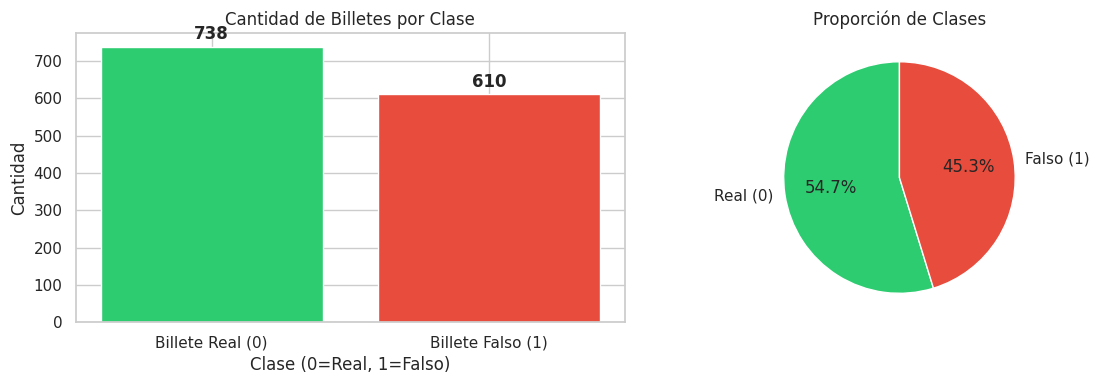

In [5]:
# Gráficos de distribución
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de barras
axes[0].bar(['Billete Real (0)', 'Billete Falso (1)'], target_counts.values,
            color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Cantidad de Billetes por Clase')
axes[0].set_xlabel('Clase (0=Real, 1=Falso)')
axes[0].set_ylabel('Cantidad')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Gráfico de pastel (proporción)
axes[1].pie(target_counts.values, labels=['Real (0)', 'Falso (1)'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Proporción de Clases')

plt.tight_layout()
plt.show()

-Distribución de variables numéricas clave
 -Mapeo de nombres originales a nombres genéricos de OpenML

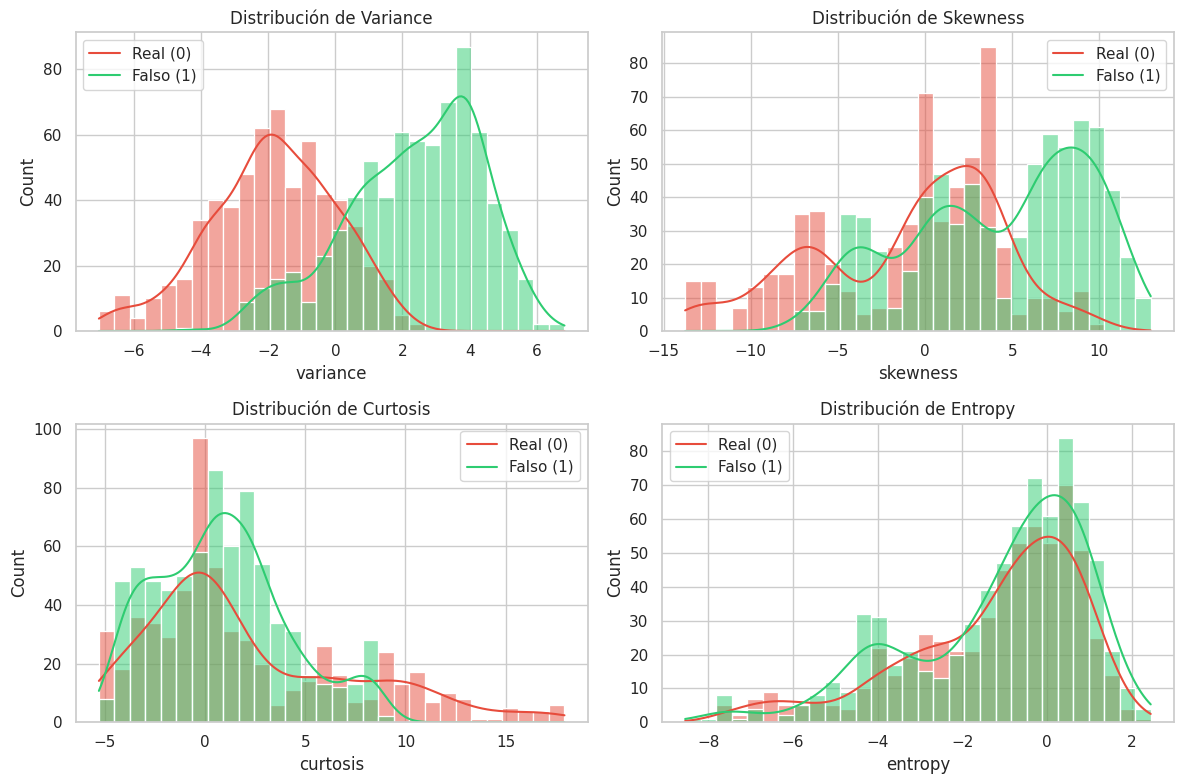

In [8]:
# Columnas numéricas de nuestro dataset de billetes
num_cols = ['variance', 'skewness', 'curtosis', 'entropy']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten() # Para iterar fácilmente sobre los 4 gráficos

for ax, col in zip(axes, num_cols):
    sns.histplot(data=df, x=col, hue='target', kde=True, ax=ax, bins=30, palette=['#2ecc71', '#e74c3c'])
    ax.set_title(f'Distribución de {col.capitalize()}')
    ax.legend(['Real (0)', 'Falso (1)'])

plt.tight_layout()
plt.show()

Matriz de Correlación " Medir numéricamente qué tan relacionadas están las variables entre sí y con el objetivo"

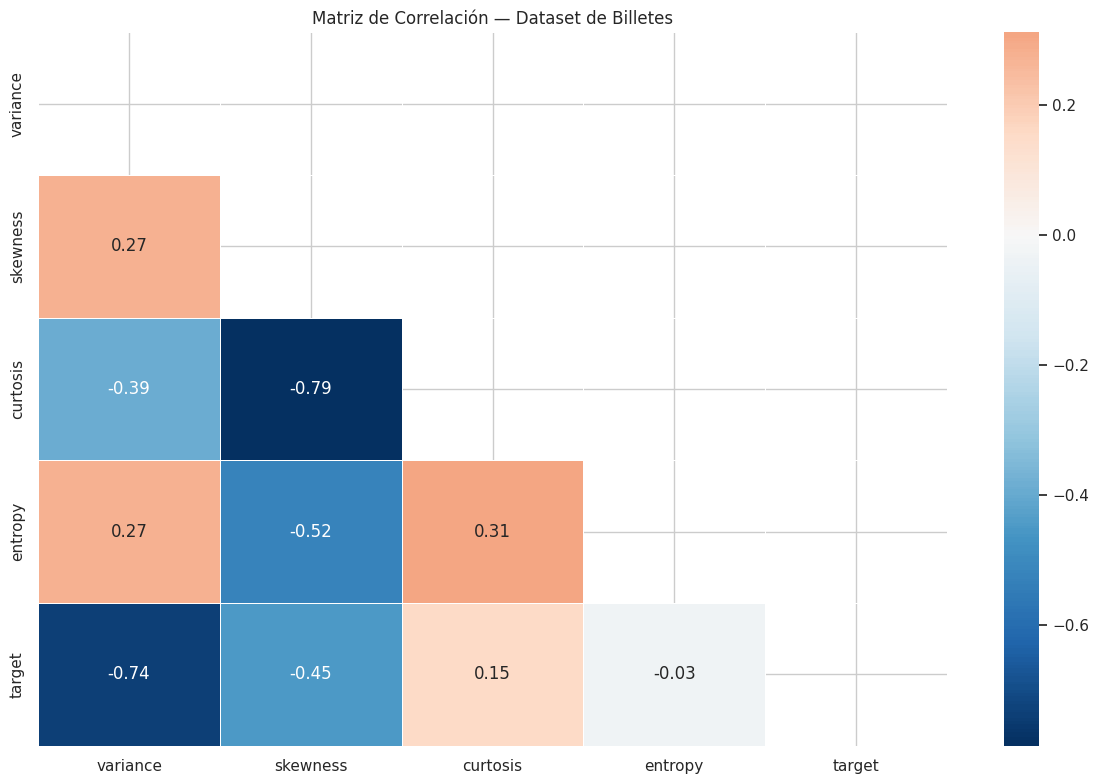

In [13]:
plt.figure(figsize=(12, 8))
corr = df.corr(numeric_only=True)

# Crear una máscara para ocultar la mitad superior del triángulo
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0, linewidths=0.5)
plt.title('Matriz de Correlación — Dataset de Billetes')
plt.tight_layout()
plt.show()

Preparación de Datos para el Modelado

In [6]:
# 1. Separar las características (X) del objetivo (y)
X = df.drop(columns='target')  # Todo menos la columna 'target'
y = df['target']               # Solo la columna 'target'

print(f'Características (X): {X.shape}')
print(f'Objetivo (y):        {y.shape}')

# 2. División en datos de Entrenamiento (80%) y Prueba (20%)
# 'stratify=y' asegura que la proporción de billetes reales/falsos se mantenga igual en ambos grupos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'\nDatos de Entrenamiento: {X_train.shape[0]} muestras')
print(f'Datos de Prueba:        {X_test.shape[0]} muestras')

print('\nProporción en Entrenamiento:')
print(y_train.value_counts(normalize=True).round(3))

print('\nProporción en Prueba:')
print(y_test.value_counts(normalize=True).round(3))

Características (X): (1348, 4)
Objetivo (y):        (1348,)

Datos de Entrenamiento: 1078 muestras
Datos de Prueba:        270 muestras

Proporción en Entrenamiento:
target
0    0.547
1    0.453
Name: proportion, dtype: float64

Proporción en Prueba:
target
0    0.548
1    0.452
Name: proportion, dtype: float64
